# Preprocess:

In [1]:
import numpy as np

1. LSTMS need input in the manner of (samples, time steps, features).
2. But our data currently is a 2D array.
3. So we need to convert it into 3D data using sliding window approach

In [2]:
def create_dataset(X, time_steps=10):
    # Here the X is a numpy array of shape (num_samples, num_features)
    # timesteps is the length of each sequence

    Xs = []

    for i in range(len(X) - time_steps + 1):
        v = X[i: (i+time_steps)]
        Xs.append(v)
    
    return np.array(Xs)

In [3]:
# Now let us load and reshape out data
scaled_2d_data = np.load('../../data/processed/training_data.npy')
print(scaled_2d_data.shape)

TIME_STEPS=10

X_train = create_dataset(scaled_2d_data, time_steps=TIME_STEPS)

print(X_train.shape)

(205836, 50)
(205827, 10, 50)


In [4]:
import mlflow

d:\Visu\JNTU\Projects\VigilantFlow\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's setup MLFlow server to track our experiments

In [5]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
EXPERIMENT_NAME = "VigilantFlow_Anomaly_Detection"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"MLflow is actively tracking under experiment: '{EXPERIMENT_NAME}'")

MLflow is actively tracking under experiment: 'VigilantFlow_Anomaly_Detection'


# Training:

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

In [7]:
n_steps = X_train.shape[1]
n_features = X_train.shape[2]

In [9]:
model = Sequential([
    LSTM(64, activation='relu', input_shape=(n_steps, n_features), return_sequences=True),
    LSTM(32, activation='relu', return_sequences=False),

    RepeatVector(n_steps),

    LSTM(32, activation='relu', return_sequences=True),
    LSTM(64, activation='relu', return_sequences=True),

    TimeDistributed(Dense(n_features))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

d:\Visu\JNTU\Projects\VigilantFlow\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 64)         │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 10, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 50)         │         3,250 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,258 (305.70 KB)

 Trainable params: 78,258 (305.70 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
import mlflow.keras
import matplotlib.pyplot as plt

In [11]:
EPOCHS = 20
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.1

TRAINING STARTED...
Epoch 1/20
2895/2895 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - loss: 0.0095 - val_loss: 0.0039
Epoch 2/20
2895/2895 ━━━━━━━━━━━━━━━━━━━━ 75s 26ms/step - loss: 0.0055 - val_loss: 0.0039
Epoch 3/20
2895/2895 ━━━━━━━━━━━━━━━━━━━━ 78s 27ms/step - loss: 0.0054 - val_loss: 0.0039
Epoch 4/20
2895/2895 ━━━━━━━━━━━━━━━━━━━━ 65s 22ms/step - loss: 0.0052 - val_loss: 0.0038
Epoch 5/20
2895/2895 ━━━━━━━━━━━━━━━━━━━━ 76s 26ms/step - loss: 0.0053 - val_loss: 0.0038
Epoch 6/20
2895/2895 ━━━━━━━━━━━━━━━━━━━━ 75s 26ms/step - loss: 0.0055 - val_loss: 0.0038
Epoch 7/20
2895/2895 ━━━━━━━━━━━━━━━━━━━━ 75s 26ms/step - loss: 0.0050 - val_loss: 0.0038
Epoch 8/20
2895/2895 ━━━━━━━━━━━━━━━━━━━━ 77s 27ms/step - loss: 0.0051 - val_loss: 0.0038
Epoch 9/20
2895/2895 ━━━━━━━━━━━━━━━━━━━━ 76s 26ms/step - loss: 0.0049 - val_loss: 0.0037
Epoch 10/20
2895/2895 ━━━━━━━━━━━━━━━━━━━━ 80s 28ms/step - loss: 0.0047 - val_loss: 0.0037
Epoch 11/20
2895/2895 ━━━━━━━━━━━━━━━━━━━━ 78s 27ms/step - loss: 0.0046 - val_l

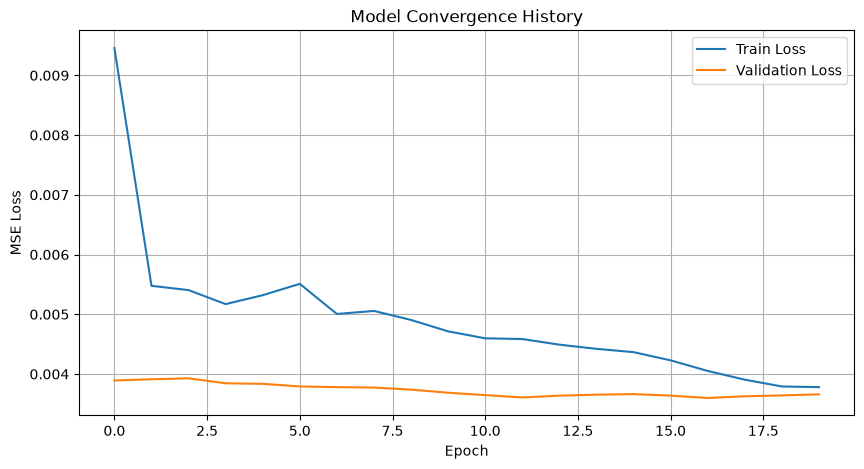

2026/07/19 14:25:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/19 14:25:41 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
Successfully registered model 'VigilantFlow_LSTM_Autoencoder'.
2026/07/19 14:26:30 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: VigilantFlow_LSTM_Autoencoder, version 1
Created version '1' of model 'VigilantFlow_LSTM_Autoencoder'.



TRAINING COMPLETE!!
🏃 View run lstm_autoencoder_baseline at: http://127.0.0.1:5000/#/experiments/1/runs/c1236a09c1714fd9b37dd9cbcb14cd25
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [13]:
with mlflow.start_run(run_name="lstm_autoencoder_baseline") as run:
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("validation_split", VALIDATION_SPLIT)
    mlflow.log_param("time_steps", X_train[1])

    print("TRAINING STARTED...")

    history = model.fit(
        X_train, X_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        shuffle = False,
        verbose = 1
    )

    mlflow.log_metric("final_train_loss", history.history['loss'][-1])
    mlflow.log_metric("final_validation_loss", history.history['val_loss'][-1])

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Convergence History')
    plt.ylabel('MSE Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)
    plt.savefig("loss_convergence.png")
    mlflow.log_artifact("loss_convergence.png")
    plt.show()

    mlflow.keras.log_model(model, artifact_path="model", registered_model_name="VigilantFlow_LSTM_Autoencoder")

    print("\nTRAINING COMPLETE!!")